# Sprint 2: Augmentation Benchmarking

# Introduction

This notebook presents a limited augmentation benchmarking study using selected methods identified in the Sprint 1 augmentation strategy survey. The aim is to evaluate the impact of different augmentation techniques on model performance and determine which methods should be used in future development.
Model performance is evaluated using Accuracy and F1 Score to ensure a balanced assessment of classification performance.

The methods tested include:

- Baseline (no augmentation)
- Time stretching
- Pitch shifting
- Gaussian noise injection
- SpecAugment
- Combined Noise + SpecAugment

To improve the technical quality of the model, a Convolutional Neural Network (CNN) is used with Mel spectrogram inputs. This approach is more suitable for audio classification, as Mel spectrograms represent both time and frequency information, allowing the CNN to learn more meaningful patterns compared to simpler models.

Each augmentation method is compared against the same no-augmentation baseline using identical dataset splits, CNN architecture, and training parameters. This ensures a fair and controlled comparison where only the augmentation method is changed.

## Advanced CNN Benchmark

In Sprint 1, several augmentation techniques were analysed to improve model performance, including SpecAugment, time stretching, pitch shifting, and Gaussian noise injection.

These include time stretching, pitch shifting, Gaussian noise injection, SpecAugment, and a combined Noise + SpecAugment approach.

In [1]:
import os
import random
import numpy as np
import librosa
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Dropout, Dense, Flatten
from tensorflow.keras.utils import to_categorical

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [2]:
#Dataset path check

dataset_path = r"C:\Users\kiran\Projects\Project-Echo\src\Prototypes\data\data_files"

print("Dataset exists:", os.path.exists(dataset_path))
print("Number of categories:", len(os.listdir(dataset_path)))

Dataset exists: True
Number of categories: 123


### Controlled Dataset Selection

To ensure a fair and manageable experiment, a subset of the dataset is selected. Five categories are used, and a fixed number of audio files are taken from each category.

This approach reduces computational load while maintaining a balanced dataset. It also supports a controlled comparison, where all augmentation methods are evaluated under the same conditions.

In [3]:
# Select Small Controlled Dataset

categories = sorted(os.listdir(dataset_path))[:5] # using 5 classes to improve the robustness of the benchmark
max_files_per_category = 40

audio_files = []
labels = []

for category in categories:
    category_path = os.path.join(dataset_path, category)

    if os.path.isdir(category_path):
        files = [
            os.path.join(category_path, file)
            for file in os.listdir(category_path)
            if file.lower().endswith((".wav", ".mp3"))
        ]

        files = files[:max_files_per_category]

        for file in files:
            audio_files.append(file)
            labels.append(category)

print("Selected categories:", categories)
print("Total files selected:", len(audio_files))


Selected categories: ['Acanthiza chrysorrhoa', 'Acanthiza lineata', 'Acanthiza nana', 'Acanthiza pusilla', 'Acanthiza reguloides']
Total files selected: 186


### Audio Augmentation Functions

The following functions implement selected augmentation techniques identified in Sprint 1. Each method is applied independently to evaluate its impact on model performance compared to the no-augmentation baseline.

A combined augmentation method (noise + SpecAugment) is also included to introduce additional variability and increase the complexity of the benchmark.

In [4]:
# Audio Augmentation Functions

def apply_augmentation(y, sr, augment_type="none"):
    if augment_type == "none" or augment_type == "specaugment":
        return y

    elif augment_type == "time_stretch":
        return librosa.effects.time_stretch(y, rate=1.1)

    elif augment_type == "pitch_shift":
        return librosa.effects.pitch_shift(y, sr=sr, n_steps=2)

    elif augment_type == "noise":
        noise = np.random.normal(0, 0.005, len(y))
        return y + noise

    elif augment_type == "noise_specaugment":
        noise = np.random.normal(0, 0.005, len(y))
        return y + noise

    return y

### Mel Spectrogram Feature Extraction

Audio signals are converted into Mel spectrograms to capture both time and frequency information in a form suitable for model training.

At this stage, SpecAugment is applied by masking selected regions of the spectrogram. This helps the model learn more general patterns instead of relying on specific details, which improves robustness and performance on unseen data.

In [5]:
# Mel Spectrogram Feature Extraction

def extract_mel_spectrogram(file_path, augment_type="none", max_pad_len=216):
    y, sr = librosa.load(file_path, sr=22050, duration=5)

    y = apply_augmentation(y, sr, augment_type)

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=128,
        n_fft=2048,
        hop_length=512
    )

    mel_db = librosa.power_to_db(mel, ref=np.max)
    
    # Apply SpecAugment on spectrogram
    if augment_type in ["specaugment", "noise_specaugment"]:
        mel_db = apply_specaugment(mel_db)

    # Pad or truncate to fixed size
    if mel_db.shape[1] < max_pad_len:
        pad_width = max_pad_len - mel_db.shape[1]
        mel_db = np.pad(mel_db, pad_width=((0, 0), (0, pad_width)), mode="constant")
    else:
        mel_db = mel_db[:, :max_pad_len]

    return mel_db

### SpecAugment Implementation

SpecAugment is applied to the Mel spectrogram by masking random regions along the time and frequency axes. 

This simulates missing or distorted parts of the audio signal, forcing the model to rely on broader patterns rather than specific features. As a result, it improves robustness and helps reduce overfitting.

In [6]:
# SpecAugment Function

def apply_specaugment(spec, time_mask_param=25, freq_mask_param=15):
    spec = spec.copy()
    mask_value = spec.min()

    freq_mask = np.random.randint(1, freq_mask_param)  # Apply frequency masking
    f0 = np.random.randint(0, max(1, spec.shape[0] - freq_mask))
    spec[f0:f0 + freq_mask, :] = mask_value

    time_mask = np.random.randint(1, time_mask_param)  # Apply time masking
    t0 = np.random.randint(0, max(1, spec.shape[1] - time_mask))
    spec[:, t0:t0 + time_mask] = mask_value

    return spec

### Dataset Preparation for Augmentation Benchmark

For each augmentation method, the dataset is prepared using the same set of audio files and labels. The dataset is first split into training, validation, and test sets to ensure a fair evaluation.

Augmentation is applied only to the training data, while validation and test data remain unchanged. This ensures that the model is evaluated on clean, unseen data.

This supports a controlled comparison, as required in the task, where the model architecture, dataset, and training parameters remain the same for all experiments, and only the augmentation method is varied.

### CNN Model Architecture

A Convolutional Neural Network (CNN) is used to classify the Mel spectrogram inputs. The model consists of multiple convolutional layers with increasing filter sizes to capture different levels of audio features.

Batch normalisation and dropout are included to improve training stability and reduce overfitting. Max pooling layers are used to reduce spatial dimensions while preserving important patterns.

The final dense layer uses a softmax activation function to produce class probabilities for multi-class classification.

In [8]:
# CNN Model

def build_cnn_model(input_shape, num_classes):
    model = Sequential([
        Conv2D(32, (3, 3), activation="relu", input_shape=input_shape),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        Conv2D(64, (3, 3), activation="relu"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        Conv2D(128, (3, 3), activation="relu"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.30),

        Flatten(),

        Dense(128, activation="relu"),
        Dropout(0.40),

        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

### Benchmark Function

This function runs the controlled benchmarking process for each augmentation method.

The dataset is split into training, validation, and test sets before augmentation is applied. Augmentation is only applied to the training data, while validation and test data remain unchanged. This creates a fair comparison because the model is evaluated on clean unseen data.

The same CNN architecture, dataset split, training settings, and evaluation metrics are used for each experiment. This ensures that the only changing factor is the augmentation method being tested.

In [9]:
# Benchmark Function

def run_cnn_benchmark(augment_type="none"):
    print(f"\nRunning benchmark for: {augment_type}")

    # Split file paths first to avoid augmenting validation/test data
    train_files, temp_files, train_labels, temp_labels = train_test_split(
        audio_files,
        labels,
        test_size=0.30,
        random_state=SEED,
        stratify=labels
    )

    val_files, test_files, val_labels, test_labels = train_test_split(
        temp_files,
        temp_labels,
        test_size=0.50,
        random_state=SEED,
        stratify=temp_labels
    )

    label_encoder = LabelEncoder()
    label_encoder.fit(labels)

    def build_features(file_list, label_list, use_augmentation=False):
        X_data = []
        y_data = []

        for file_path, label in zip(file_list, label_list):
            try:
                method = augment_type if use_augmentation else "none"
                spec = extract_mel_spectrogram(file_path, method)

                X_data.append(spec)
                y_data.append(label)

            except Exception as e:
                print("Skipped:", file_path, e)

        X_data = np.array(X_data)
        X_data = X_data[..., np.newaxis]

        y_encoded = label_encoder.transform(y_data)
        y_encoded = to_categorical(y_encoded, num_classes=len(label_encoder.classes_))

        return X_data, y_encoded

    # Augmentation only applied to training data
    X_train, y_train = build_features(train_files, train_labels, use_augmentation=True)

    # Validation and test data stay clean
    X_val, y_val = build_features(val_files, val_labels, use_augmentation=False)
    X_test, y_test = build_features(test_files, test_labels, use_augmentation=False)

    model = build_cnn_model(
        input_shape=X_train.shape[1:],
        num_classes=len(label_encoder.classes_)
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=15,
        batch_size=16,
        verbose=1
    )

    # Training curve
    plt.figure()
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"Training Curve - {augment_type}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    # Prediction
    y_pred_prob = model.predict(X_test)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = np.argmax(y_test, axis=1)

    # Metrics
    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="weighted")

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_encoder.classes_
    )
    disp.plot(xticks_rotation=45)
    plt.title(f"Confusion Matrix - {augment_type}")
    plt.show()

    return accuracy, f1, y_true, y_pred, label_encoder, history

### Running the Benchmark

Each augmentation method is evaluated using the same dataset, model architecture, and training configuration to ensure a fair comparison.

The benchmark is executed for all selected methods, including a combined augmentation approach. Accuracy and F1 score are recorded for each method to measure performance.

The results are organised into a table to make it easy to compare methods and identify which augmentation techniques are most effective.


Running benchmark for: none


C:\Users\kiran\anaconda3\envs\projectecho\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Epoch 1/15
9/9 [==============================] - 7s 640ms/step - loss: 18.7810 - accuracy: 0.2462 - val_loss: 5.5527 - val_accuracy: 0.2143
Epoch 2/15
9/9 [==============================] - 7s 805ms/step - loss: 4.1559 - accuracy: 0.4000 - val_loss: 6.6974 - val_accuracy: 0.2857
Epoch 3/15
9/9 [==============================] - 4s 500ms/step - loss: 1.6717 - accuracy: 0.5077 - val_loss: 5.3665 - val_accuracy: 0.2857
Epoch 4/15
9/9 [==============================] - 4s 479ms/step - loss: 1.1316 - accuracy: 0.5308 - val_loss: 1.9404 - val_accuracy: 0.3571
Epoch 5/15
9/9 [==============================] - 5s 538ms/step - loss: 1.0514 - accuracy: 0.6154 - val_loss: 2.6170 - val_accuracy: 0.2857
Epoch 6/15
9/9 [==============================] - 6s 633ms/step - loss: 1.1156 - accuracy: 0.6154 - val_loss: 2.4878 - val_accuracy: 0.2500
Epoch 7/15
9/9 [==============================] - 6s 648ms/step - loss: 1.0733 - accuracy: 0.5769 - val_loss: 1.5437 - val_accuracy: 0.2143
Epoch 8/15
9/9 [===

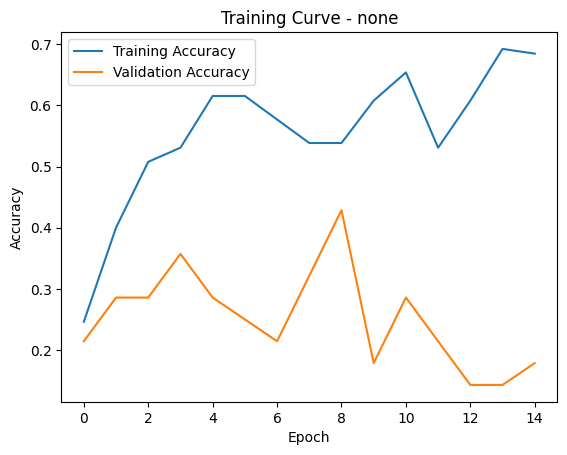

1/1 [==============================] - 0s 247ms/step


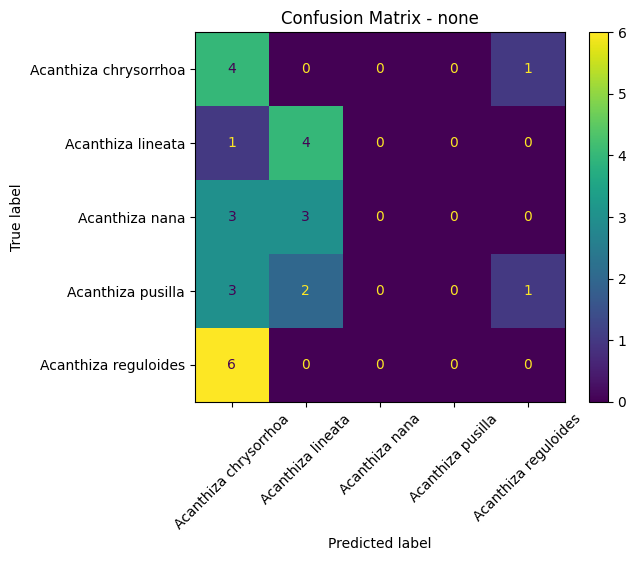

none: Accuracy=0.286, F1=0.167

Running benchmark for: time_stretch
Epoch 1/15
9/9 [==============================] - 5s 512ms/step - loss: 19.2204 - accuracy: 0.1923 - val_loss: 8.9528 - val_accuracy: 0.2143
Epoch 2/15
9/9 [==============================] - 3s 273ms/step - loss: 8.0674 - accuracy: 0.3769 - val_loss: 3.7880 - val_accuracy: 0.2500
Epoch 3/15
9/9 [==============================] - 3s 332ms/step - loss: 3.2576 - accuracy: 0.4769 - val_loss: 4.8679 - val_accuracy: 0.3571
Epoch 4/15
9/9 [==============================] - 4s 402ms/step - loss: 2.0821 - accuracy: 0.4615 - val_loss: 2.7288 - val_accuracy: 0.3571
Epoch 5/15
9/9 [==============================] - 4s 485ms/step - loss: 1.8914 - accuracy: 0.4385 - val_loss: 1.9323 - val_accuracy: 0.2500
Epoch 6/15
9/9 [==============================] - 5s 571ms/step - loss: 1.4278 - accuracy: 0.4615 - val_loss: 1.7721 - val_accuracy: 0.2857
Epoch 7/15
9/9 [==============================] - 6s 662ms/step - loss: 1.3172 - accuracy: 

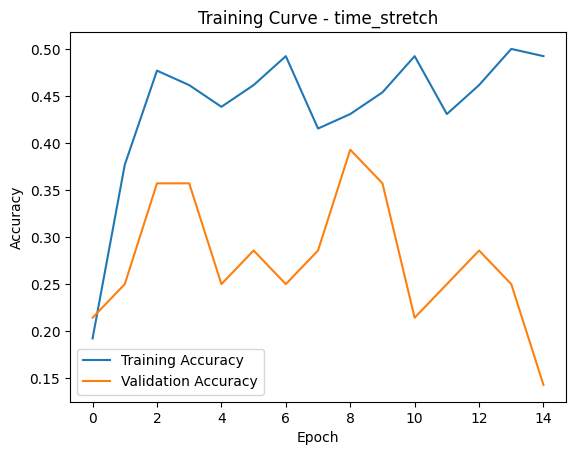

1/1 [==============================] - 0s 387ms/step


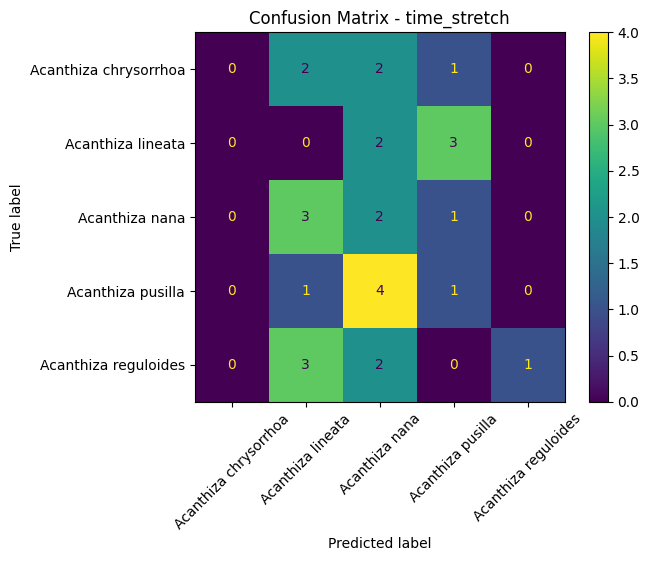

time_stretch: Accuracy=0.143, F1=0.145

Running benchmark for: pitch_shift
Epoch 1/15
9/9 [==============================] - 9s 872ms/step - loss: 16.4030 - accuracy: 0.2846 - val_loss: 9.6440 - val_accuracy: 0.2143
Epoch 2/15
9/9 [==============================] - 8s 848ms/step - loss: 6.5855 - accuracy: 0.3615 - val_loss: 15.6236 - val_accuracy: 0.2500
Epoch 3/15
9/9 [==============================] - 7s 728ms/step - loss: 3.1597 - accuracy: 0.4538 - val_loss: 1.6983 - val_accuracy: 0.1429
Epoch 4/15
9/9 [==============================] - 6s 584ms/step - loss: 2.0003 - accuracy: 0.3846 - val_loss: 1.9725 - val_accuracy: 0.1786
Epoch 5/15
9/9 [==============================] - 6s 708ms/step - loss: 1.9967 - accuracy: 0.3692 - val_loss: 1.6248 - val_accuracy: 0.2500
Epoch 6/15
9/9 [==============================] - 7s 826ms/step - loss: 1.3509 - accuracy: 0.4538 - val_loss: 1.4950 - val_accuracy: 0.3214
Epoch 7/15
9/9 [==============================] - 8s 849ms/step - loss: 1.2155 - ac

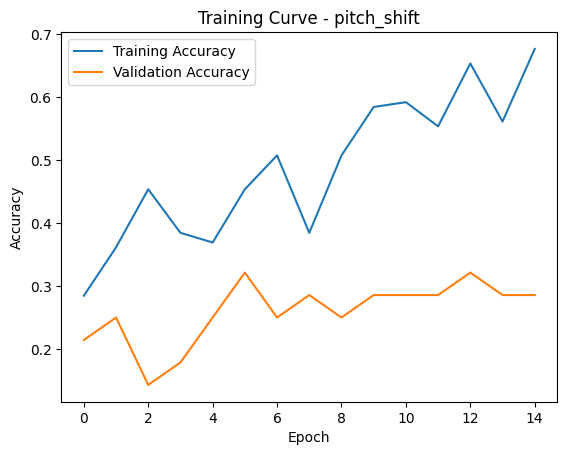

1/1 [==============================] - 0s 318ms/step


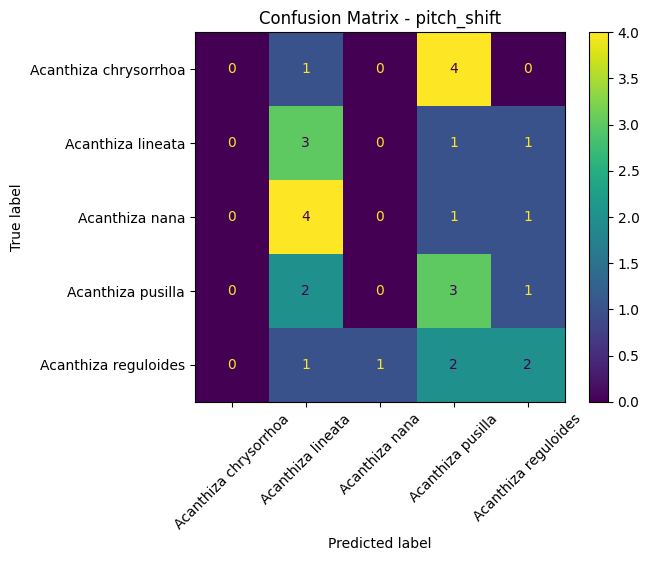

pitch_shift: Accuracy=0.286, F1=0.221

Running benchmark for: noise
Epoch 1/15
9/9 [==============================] - 8s 839ms/step - loss: 15.3401 - accuracy: 0.2308 - val_loss: 5.0407 - val_accuracy: 0.2143
Epoch 2/15
9/9 [==============================] - 10s 1s/step - loss: 4.4093 - accuracy: 0.4462 - val_loss: 5.0534 - val_accuracy: 0.2143
Epoch 3/15
9/9 [==============================] - 8s 803ms/step - loss: 1.8144 - accuracy: 0.5385 - val_loss: 2.7458 - val_accuracy: 0.2500
Epoch 4/15
9/9 [==============================] - 8s 845ms/step - loss: 1.6656 - accuracy: 0.3231 - val_loss: 3.2031 - val_accuracy: 0.2500
Epoch 5/15
9/9 [==============================] - 9s 1s/step - loss: 1.1572 - accuracy: 0.5923 - val_loss: 3.3537 - val_accuracy: 0.2143
Epoch 6/15
9/9 [==============================] - 9s 1s/step - loss: 1.3975 - accuracy: 0.4462 - val_loss: 1.6308 - val_accuracy: 0.2857
Epoch 7/15
9/9 [==============================] - 10s 1s/step - loss: 1.1757 - accuracy: 0.4538 - v

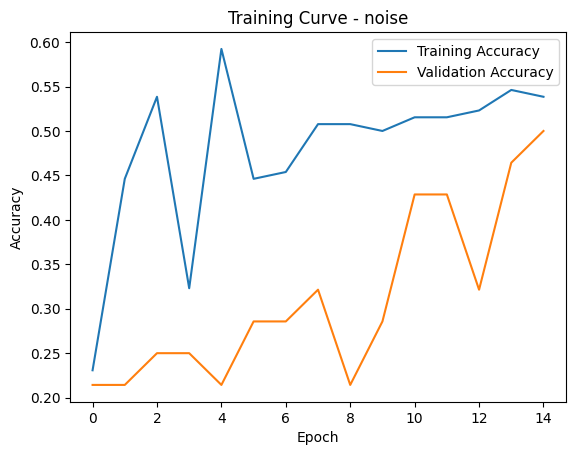

1/1 [==============================] - 0s 359ms/step


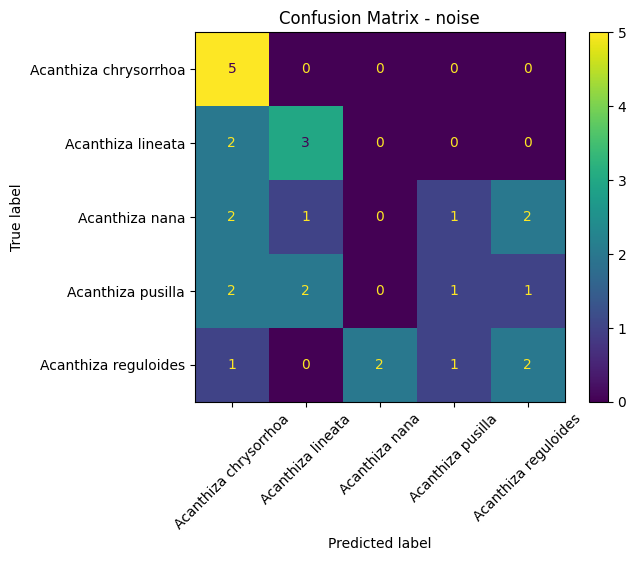

noise: Accuracy=0.393, F1=0.328

Running benchmark for: specaugment
Epoch 1/15
9/9 [==============================] - 7s 644ms/step - loss: 18.2277 - accuracy: 0.2308 - val_loss: 6.4039 - val_accuracy: 0.2143
Epoch 2/15
9/9 [==============================] - 6s 674ms/step - loss: 6.9361 - accuracy: 0.2846 - val_loss: 2.2761 - val_accuracy: 0.2500
Epoch 3/15
9/9 [==============================] - 5s 589ms/step - loss: 2.0354 - accuracy: 0.3231 - val_loss: 1.6575 - val_accuracy: 0.2500
Epoch 4/15
9/9 [==============================] - 6s 634ms/step - loss: 1.7167 - accuracy: 0.2462 - val_loss: 1.5575 - val_accuracy: 0.3214
Epoch 5/15
9/9 [==============================] - 5s 548ms/step - loss: 1.8151 - accuracy: 0.3231 - val_loss: 1.5076 - val_accuracy: 0.3214
Epoch 6/15
9/9 [==============================] - 5s 566ms/step - loss: 1.4767 - accuracy: 0.3308 - val_loss: 1.5498 - val_accuracy: 0.2857
Epoch 7/15
9/9 [==============================] - 5s 572ms/step - loss: 1.3710 - accuracy: 

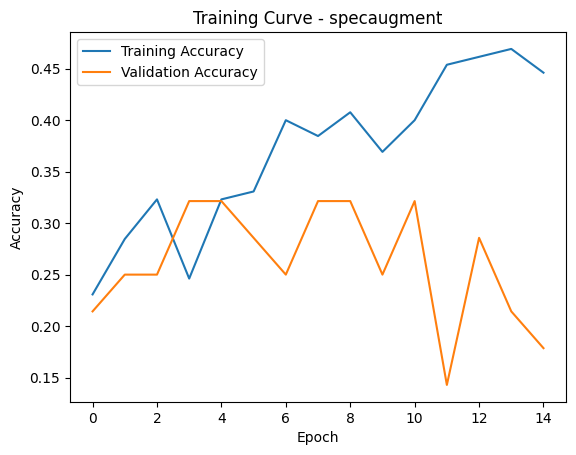

1/1 [==============================] - 0s 426ms/step


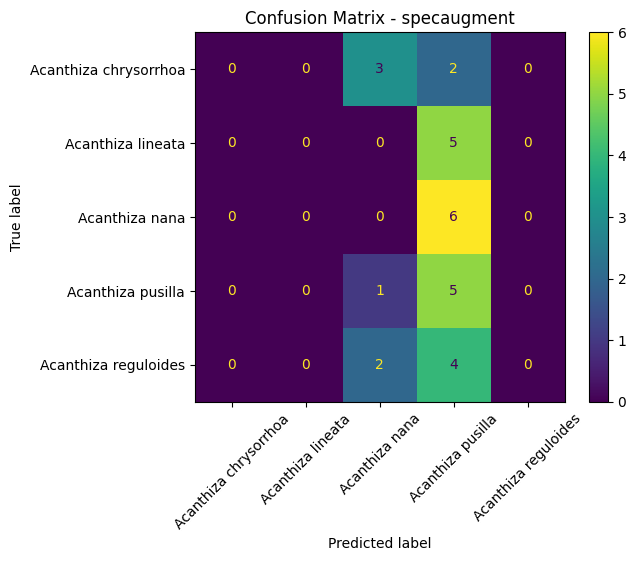

specaugment: Accuracy=0.179, F1=0.077

Running benchmark for: noise_specaugment
Epoch 1/15
9/9 [==============================] - 4s 369ms/step - loss: 13.4133 - accuracy: 0.2769 - val_loss: 4.5821 - val_accuracy: 0.2500
Epoch 2/15
9/9 [==============================] - 5s 580ms/step - loss: 7.5768 - accuracy: 0.3846 - val_loss: 3.0095 - val_accuracy: 0.1429
Epoch 3/15
9/9 [==============================] - 5s 600ms/step - loss: 2.7970 - accuracy: 0.5615 - val_loss: 2.1440 - val_accuracy: 0.2143
Epoch 4/15
9/9 [==============================] - 5s 592ms/step - loss: 2.0190 - accuracy: 0.5000 - val_loss: 1.5920 - val_accuracy: 0.2143
Epoch 5/15
9/9 [==============================] - 5s 601ms/step - loss: 1.4963 - accuracy: 0.4538 - val_loss: 1.7494 - val_accuracy: 0.2143
Epoch 6/15
9/9 [==============================] - 5s 578ms/step - loss: 1.3026 - accuracy: 0.5385 - val_loss: 2.1072 - val_accuracy: 0.2143
Epoch 7/15
9/9 [==============================] - 5s 586ms/step - loss: 1.1260 

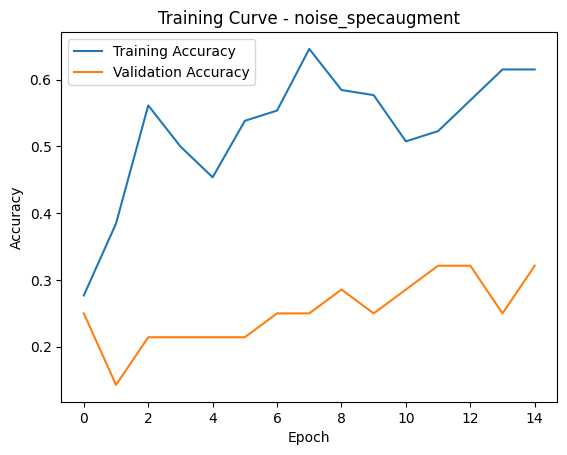

1/1 [==============================] - 0s 358ms/step


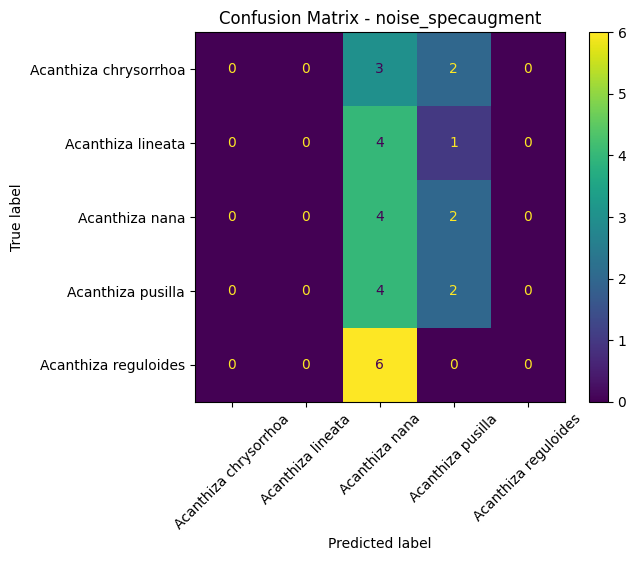

noise_specaugment: Accuracy=0.214, F1=0.129


In [10]:
# Run Benchmark

methods = [
    "none",
    "time_stretch",
    "pitch_shift",
    "noise",
    "specaugment",
    "noise_specaugment"
]

results = []
saved_outputs = {}

for method in methods:
    acc, f1, y_true, y_pred, label_encoder, history = run_cnn_benchmark(method)

    results.append([method, acc, f1])

    saved_outputs[method] = {
        "y_true": y_true,
        "y_pred": y_pred,
        "label_encoder": label_encoder,
        "history": history
    }

    print(f"{method}: Accuracy={acc:.3f}, F1={f1:.3f}")

In [13]:
# Results Table

results_df = pd.DataFrame(
    results,
    columns=["Method", "Accuracy", "F1 Score"]
)

results_df = results_df.sort_values(by="Accuracy", ascending=False)
results_df = results_df.round(3)
results_df = results_df.reset_index(drop=True)

print("\n Benchmark Results Summary")
# Add decision column
decisions = {
    "noise": "Keep",
    "pitch_shift": "Defer",
    "noise_specaugment": "Defer",
    "specaugment": "Drop",
    "time_stretch": "Drop",
    "none": "Reference"
}

results_df["Decision"] = results_df["Method"].map(decisions)

display(results_df)


 Benchmark Results Summary


,Method,Accuracy,F1 Score,Decision
0,noise,0.393,0.328,Keep
1,none,0.286,0.167,Reference
2,pitch_shift,0.286,0.221,Defer
3,noise_specaugment,0.214,0.129,Defer
4,specaugment,0.179,0.077,Drop
5,time_stretch,0.143,0.145,Drop


### Results Summary

The results show that different augmentation methods have varying effects on model performance.

Noise injection achieved the highest accuracy (0.393) and F1 score (0.328), showing a clear improvement over the baseline model. This suggests that adding noise helped the model generalise better.

The baseline and pitch shifting produced similar accuracy results, although pitch shifting slightly improved the F1 score. This indicates a minor benefit.

SpecAugment, time stretching, and the combined method (noise + SpecAugment) performed worse than the baseline. This may be due to excessive distortion or loss of important audio features.

Overall, noise injection was the most effective method in this benchmark.

### Final Recommendations

| Method | Accuracy | F1 Score | Decision |
|--------|---------:|---------:|----------|
| Noise | 0.393 | 0.328 | Keep |
| Pitch Shift | 0.286 | 0.221 | Defer |
| Noise + SpecAugment | 0.214 | 0.129 | Defer |
| SpecAugment | 0.179 | 0.077 | Drop |
| Time Stretch | 0.143 | 0.145 | Drop |
| None (baseline) | 0.286 | 0.167 | Reference only |

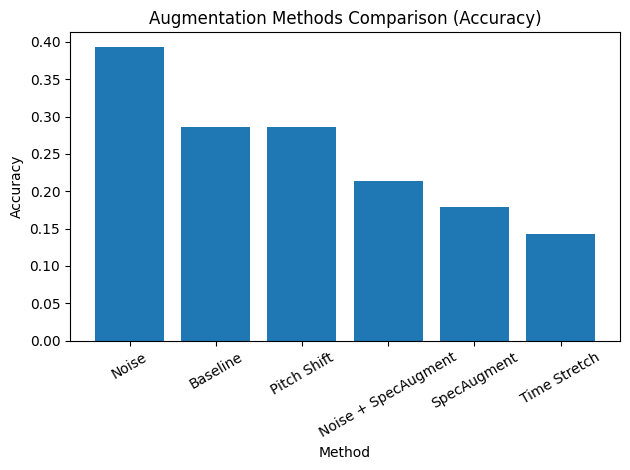

In [12]:
import matplotlib.pyplot as plt

# Create a simple bar chart for accuracy comparison
plt.figure()

# Use clean method names for better readability
method_names = results_df["Method"].replace({
    "none": "Baseline",
    "time_stretch": "Time Stretch",
    "pitch_shift": "Pitch Shift",
    "noise": "Noise",
    "specaugment": "SpecAugment",
    "noise_specaugment": "Noise + SpecAugment"
})

plt.bar(method_names, results_df["Accuracy"])

plt.title("Augmentation Methods Comparison (Accuracy)")
plt.xlabel("Method")
plt.ylabel("Accuracy")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Accuracy Comparison

The bar chart shows a comparison of model accuracy across different augmentation methods.

From the graph, it is clear that the noise augmentation method achieved the highest accuracy. This supports the results observed in the benchmark table, where noise performed better than all other methods.

The baseline model and pitch shifting produced similar accuracy values, suggesting that pitch shifting provides only a slight improvement compared to the baseline.

SpecAugment and time stretching resulted in lower accuracy, suggesting that these methods may have distorted important features in the audio data.

Overall, the graph supports the earlier results and shows that noise augmentation is the most effective method for this dataset.

## Results and Discussion

The results compare the performance of each augmentation method against the baseline model using the same dataset and CNN configuration.

The baseline model achieved an accuracy of 0.286 and an F1 score of 0.167. Pitch shifting produced similar accuracy but showed a small improvement in F1 score. Time stretching performed worse than the baseline, indicating that it may negatively affect important audio features.

Noise injection achieved the best performance, with an accuracy of 0.393 and an F1 score of 0.328. This shows a clear improvement over the baseline and suggests that adding noise helps the model generalise better.

SpecAugment and the combined method (noise + SpecAugment) resulted in lower performance compared to noise alone. This may be due to excessive distortion of the audio signals.

Overall, noise injection showed the best performance in this benchmark, while other methods showed limited or inconsistent improvements.

## Final Recommendations

- Noise Injection – Keep (best performance)
- Pitch Shift – Defer (small improvement only)
- Noise + SpecAugment – Defer (not better than noise alone)
- SpecAugment – Drop (low performance)
- Time Stretch – Drop (worst performance)
- Baseline – Reference only, not an augmentation method

## Conclusion

This sprint focused on benchmarking selected audio augmentation techniques identified in Sprint 1 using a CNN-based model.

The results show that different augmentation methods impact model performance in different ways. Noise injection provided the most consistent improvement and will be carried forward to Sprint 3 for further optimisation.

Other techniques such as pitch shifting may require tuning, while methods like time stretching and SpecAugment did not perform well in this setup.

Future work will focus on refining the selected methods and exploring ways to improve overall model generalisation.